## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Dataset

Grouped Complaints by ZIP code, month and company:

In [4]:
df = pd.read_csv("/Users/lucamilani/Desktop/ASSIGNMENTS/merged_aggregated.csv")
# df= pd.read_scv("C:/Users/lasko/Documents/Bocconi/3rd_Semester/Finance with Big Data/merged_aggregated.csv")
df = df.iloc[:, 1:]
df.head()

,ZIP code,month,Company,num_complaints,income_quintile,minority_quintile,education_quintile,population_total
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,5.0,5.0,5.0,40026.0
1,60620,2025-01,"Early Warning Services, LLC",87,1.0,5.0,3.0,66514.0
2,33071,2012-06,Ocwen Financial Corporation,74,5.0,5.0,5.0,40026.0
3,60629,2025-01,"Early Warning Services, LLC",66,1.0,5.0,1.0,114453.0
4,60628,2025-01,"Block, Inc.",61,2.0,5.0,3.0,62832.0


In [6]:
ai_adopt_df = pd.read_excel("ai_adoption.xlsx")
ai_adopt_df = ai_adopt_df[['Company', 'Fintech?']]
ai_adopt_df.head()

,Company,Fintech?
0,"EQUIFAX, INC.",credit bureat
1,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",credit bureat
2,Experian Information Solutions Inc.,credit bureat
3,"BANK OF AMERICA, NATIONAL ASSOCIATION",non fintech
4,WELLS FARGO & COMPANY,non fintech


For resarch purposes, we will be focusing only on the first 100 institutions with the greatest number of complaints obtained from the Consumer Financial Protection Bureau, further including the greatest fintechs.

In [7]:
# Keep first 100 rows
first_100 = ai_adopt_df.iloc[:100]

# Keep fintechs beyond first 100
fintechs_beyond_100 = ai_adopt_df.iloc[100:][ai_adopt_df.iloc[100:]['Fintech?'] == 'fintech']

# Final
filtered_ai_adopt_df = pd.concat([first_100, fintechs_beyond_100], ignore_index=True)
filtered_ai_adopt_df = filtered_ai_adopt_df[(filtered_ai_adopt_df['Fintech?'] == 'non fintech') | (filtered_ai_adopt_df['Fintech?'] == 'fintech')]
print(len(filtered_ai_adopt_df))
filtered_ai_adopt_df.head()

108


,Company,Fintech?
3,"BANK OF AMERICA, NATIONAL ASSOCIATION",non fintech
4,WELLS FARGO & COMPANY,non fintech
5,JPMORGAN CHASE & CO.,non fintech
6,CAPITAL ONE FINANCIAL CORPORATION,non fintech
7,"CITIBANK, N.A.",non fintech


In [8]:
fintechs = filtered_ai_adopt_df[(filtered_ai_adopt_df['Fintech?'] == 'fintech')]
print(f'Number of considered Fintechs: {len(fintechs)}')
non_fintechs = filtered_ai_adopt_df[(filtered_ai_adopt_df['Fintech?'] == 'non fintech')]
print(f'Number of considered Non-Fintechs: {len(non_fintechs)}')

Number of considered Fintechs: 26
Number of considered Non-Fintechs: 82


Our filtering approach resulted in obtaining the following number of fintech and non-fintech institutions for research purposes:
- **Fintechs:** 26
- **Non-Fintechs:** 82

In [9]:
filtered_ai_adopt_df['Fintech'] = (filtered_ai_adopt_df['Fintech?'].str.lower() == 'fintech').astype(int)
filtered_ai_adopt_df = filtered_ai_adopt_df.drop(columns=['Fintech?'])

Merging the 2 datasets on the institution:

In [10]:
filtered_ai_adopt_df['Company_lower'] = filtered_ai_adopt_df['Company'].str.lower()
df['Company_lower'] = df['Company'].str.lower()

merged_df = df.merge(
    filtered_ai_adopt_df[['Company_lower', 'Fintech']],
    on='Company_lower',
    how='left'
)

merged_df = merged_df.drop(columns=['Company_lower'])
merged_df.head()

,ZIP code,month,Company,num_complaints,income_quintile,minority_quintile,education_quintile,population_total,Fintech
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,5.0,5.0,5.0,40026.0,0.0
1,60620,2025-01,"Early Warning Services, LLC",87,1.0,5.0,3.0,66514.0,1.0
2,33071,2012-06,Ocwen Financial Corporation,74,5.0,5.0,5.0,40026.0,0.0
3,60629,2025-01,"Early Warning Services, LLC",66,1.0,5.0,1.0,114453.0,1.0
4,60628,2025-01,"Block, Inc.",61,2.0,5.0,3.0,62832.0,1.0


In [11]:
print(f'Number of records: {len(merged_df)}')

Number of records: 2369594


In [12]:
merged_df.isnull().sum()

ZIP code                   0
month                      0
Company                    0
num_complaints             0
income_quintile         3323
minority_quintile         83
education_quintile       394
population_total           0
Fintech               665682
dtype: int64

Dropping missing values:

In [13]:
merged_df = merged_df.dropna()
print(f'Number of records AFTER: {len(merged_df)}')


Number of records AFTER: 1701381


Dataset preparation - dummies:

In [14]:
cols_to_encode = ['income_quintile', 'minority_quintile', 'education_quintile', 'Fintech']

for col in cols_to_encode:
    merged_df[col] = merged_df[col].astype('category').cat.codes

merged_df = pd.get_dummies(merged_df, columns=cols_to_encode, drop_first=False)
merged_df.head()

,ZIP code,month,Company,num_complaints,population_total,income_quintile_0,income_quintile_1,income_quintile_2,income_quintile_3,income_quintile_4,minority_quintile_0,minority_quintile_1,minority_quintile_2,minority_quintile_3,minority_quintile_4,education_quintile_0,education_quintile_1,education_quintile_2,education_quintile_3,education_quintile_4,Fintech_0,Fintech_1
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False
1,60620,2025-01,"Early Warning Services, LLC",87,66514.0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True
2,33071,2012-06,Ocwen Financial Corporation,74,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False
3,60629,2025-01,"Early Warning Services, LLC",66,114453.0,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True
4,60628,2025-01,"Block, Inc.",61,62832.0,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True


In [15]:
merged_df = merged_df.rename(columns={'month': 'month_year'})
merged_df['month_year'] = pd.to_datetime(merged_df['month_year'], format='%Y-%m')
merged_df['month'] = merged_df['month_year'].dt.month

In [16]:
merged_df = pd.get_dummies(merged_df, columns=['month'], drop_first=False)
merged_df.head()

,ZIP code,month_year,Company,num_complaints,population_total,income_quintile_0,income_quintile_1,income_quintile_2,income_quintile_3,income_quintile_4,minority_quintile_0,minority_quintile_1,minority_quintile_2,minority_quintile_3,minority_quintile_4,education_quintile_0,education_quintile_1,education_quintile_2,education_quintile_3,education_quintile_4,Fintech_0,Fintech_1,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,33071,2012-06-01,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False
1,60620,2025-01-01,"Early Warning Services, LLC",87,66514.0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False
2,33071,2012-06-01,Ocwen Financial Corporation,74,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False
3,60629,2025-01-01,"Early Warning Services, LLC",66,114453.0,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False
4,60628,2025-01-01,"Block, Inc.",61,62832.0,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False


Adding monotonic numeric index of time to account for **time trend**:

In [17]:
merged_df['time_trend'] = merged_df['month_year'].rank().astype(int)
merged_df.head(1)

,ZIP code,month_year,Company,num_complaints,population_total,income_quintile_0,income_quintile_1,income_quintile_2,income_quintile_3,income_quintile_4,minority_quintile_0,minority_quintile_1,minority_quintile_2,minority_quintile_3,minority_quintile_4,education_quintile_0,education_quintile_1,education_quintile_2,education_quintile_3,education_quintile_4,Fintech_0,Fintech_1,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,time_trend
0,33071,2012-06-01,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,27237


To account for **differences in population size across ZIP codes**, which could otherwise distort the results of our OLS regression, we normalize the number of complaints by dividing it by the population, obtaining the **number of complaints per 1,000 inhabitants** (norm_num_complaints):

In [18]:
merged_df['norm_num_complaints'] = (merged_df['num_complaints'] / merged_df['population_total']) * 1000

In [19]:
merged_df['norm_num_complaints'].describe()

count    1.701381e+06
mean     5.606848e-02
std      5.796299e-01
min      7.393387e-03
25%      2.122331e-02
50%      3.000300e-02
75%      4.456527e-02
max      2.500000e+02
Name: norm_num_complaints, dtype: float64

ZIP codes with large populations and few complaints produce very small ratios — often close to 0 (as indicated by the mean). Only a few ZIP codes with small populations and high complaint counts will have big ratios (as indicated by the maximum). As a result, the data is **heavily right-skewed**.

To account for this, we will perform **log-transformation** of the normalized number of complaints per 1,000 inhabitants:

In [20]:
merged_df['log_norm_num_complaints'] = np.log1p(merged_df['norm_num_complaints'])
merged_df['log_norm_num_complaints'].describe()

count    1.701381e+06
mean     4.746442e-02
std      8.710332e-02
min      7.366190e-03
25%      2.100123e-02
50%      2.956172e-02
75%      4.360079e-02
max      5.525453e+00
Name: log_norm_num_complaints, dtype: float64

Even though the log-transformation did not improve the skewness of the distribution, we'll continue using the log-transformed variable in the OLS model, as it **helps reduce
the influence of extreme outliers** and allows for **more stable estimation and interpretation**.

## Visualizations

**Number of complaints over time** - fintechs vs non-fintechs:

In [21]:
complaints_by_type = (
    merged_df
    .groupby(['month_year', 'Fintech_1'], as_index=False)['num_complaints']
    .sum()
)

complaints_by_type = complaints_by_type[['Fintech_1', 'month_year', 'num_complaints']]
complaints_by_type = complaints_by_type.rename(columns={'Fintech_1': 'Fintech?'})
complaints_by_type['Fintech?'] = complaints_by_type['Fintech?'].map({True: 'Fintech', False: 'Non-Fintech'})
complaints_by_type.head()

,Fintech?,month_year,num_complaints
0,Non-Fintech,2011-12-01,2276
1,Fintech,2011-12-01,62
2,Non-Fintech,2012-01-01,2851
3,Fintech,2012-01-01,81
4,Non-Fintech,2012-02-01,3131


In [22]:
ct = complaints_by_type.copy()
ct['month_year'] = pd.to_datetime(ct['month_year'], errors='coerce')

# pivot - months as index, types as columns
pivot = (
    ct.pivot_table(
        index='month_year',
        columns='Fintech?',
        values='num_complaints',
        aggfunc='sum'
    )
    .fillna(0)
    .sort_index()
)

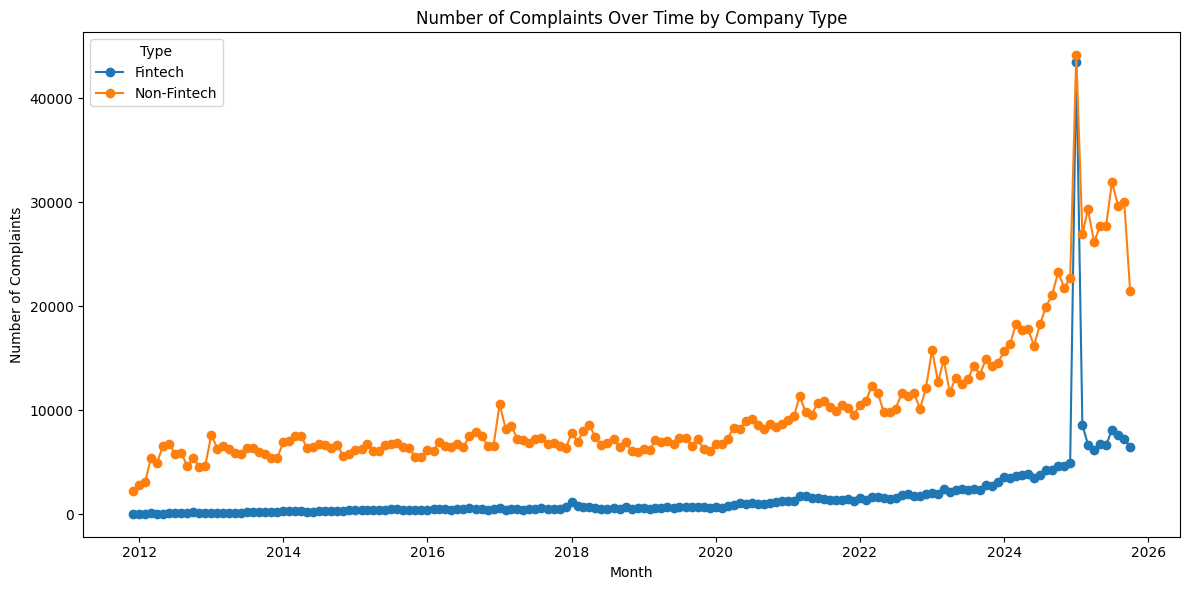

In [23]:
plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col)

plt.title('Number of Complaints Over Time by Company Type')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

Log-scaling to get insights into the trends over time:

In [24]:
ct_log = complaints_by_type.copy()
ct_log['log_num_complaints'] = np.log1p(ct_log['num_complaints'])

ct_log['month_year'] = pd.to_datetime(ct_log['month_year'], errors='coerce')

# Pivot
pivot_log = (
    ct_log.pivot_table(
        index='month_year',
        columns='Fintech?',
        values='log_num_complaints',
        aggfunc='mean'
    )
    .fillna(0)
    .sort_index()
)

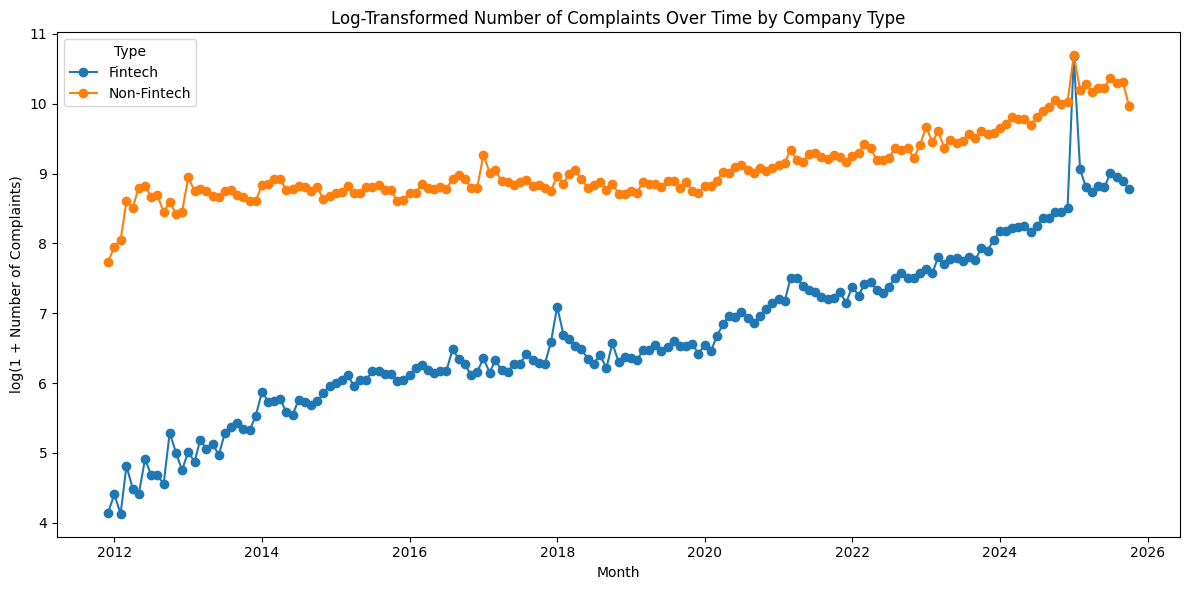

In [25]:
# Plot
plt.figure(figsize=(12, 6))
for col in pivot_log.columns:
    plt.plot(pivot_log.index, pivot_log[col], marker='o', label=col)

plt.title('Log-Transformed Number of Complaints Over Time by Company Type')
plt.xlabel('Month')
plt.ylabel('log(1 + Number of Complaints)')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

**Heatmap with correlations:**

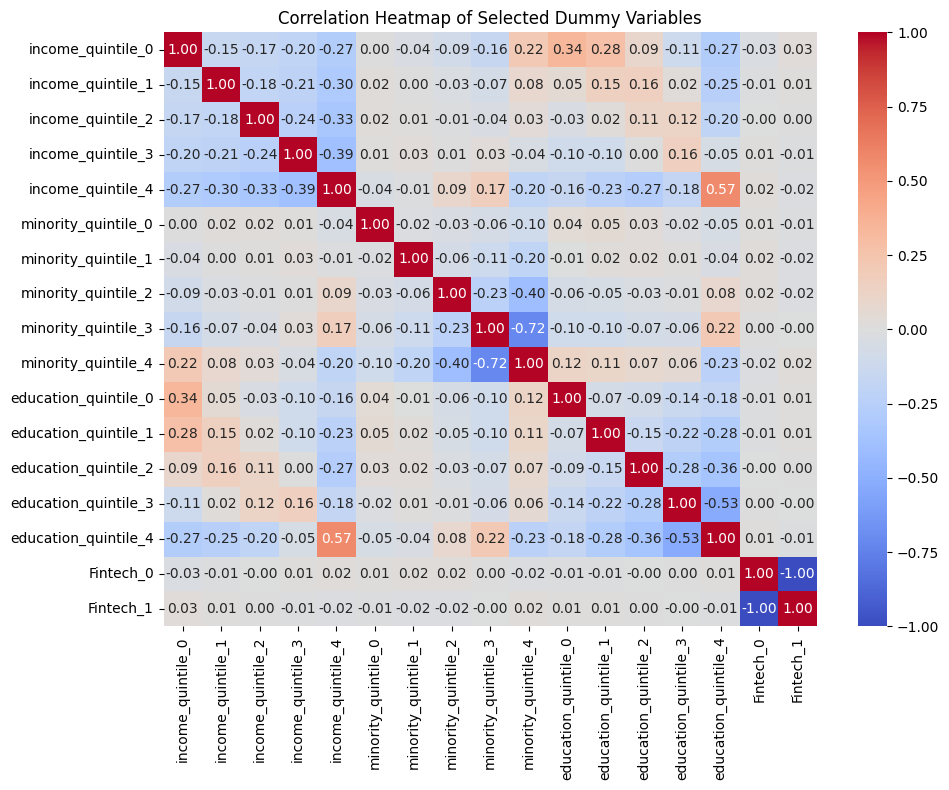

In [23]:
prefixes = ('income_quintile_', 'minority_quintile_', 'education_quintile_', 'Fintech_')
corr_df = merged_df[[col for col in merged_df.columns if col.startswith(prefixes)]]

# Correlation matrix
corr_matrix = corr_df.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Dummy Variables')
plt.tight_layout()
plt.show()

We checked for multicollinearity across quartile variables using a correlation heatmap. Education and income quartiles were moderately correlated (ρ≈0.5) for Q4, so to avoid redundant information we excluded education quartiles and retained income and minority quartiles.

## Data Exploration

**Number of complaints** per Company:

In [24]:
complaints_by_company = (
    merged_df
    .groupby(['Company', 'Fintech_1'], as_index=False)['num_complaints']
    .sum()
)

complaints_by_company_sorted = complaints_by_company.sort_values(
    by='num_complaints', ascending=False
)

# Top 10 companies with most complaints
top_10 = complaints_by_company_sorted.head(10)
print("Top 10 companies with most complaints:")
print(top_10)

# Bottom 10 companies with fewest complaints
bottom_10 = complaints_by_company_sorted.tail(10)
print("\nBottom 10 companies with fewest complaints:")
print(bottom_10)

Top 10 companies with most complaints:
                                   Company  Fintech_1  num_complaints
7    BANK OF AMERICA, NATIONAL ASSOCIATION      False          144704
107                  WELLS FARGO & COMPANY      False          132998
57                    JPMORGAN CHASE & CO.      False          130696
16       CAPITAL ONE FINANCIAL CORPORATION      False          120125
22                          CITIBANK, N.A.      False          102537
93                     SYNCHRONY FINANCIAL      False           57330
85         Resurgent Capital Services L.P.      False           43566
12                             Block, Inc.       True           43190
4                 AMERICAN EXPRESS COMPANY       True           41388
37               ENCORE CAPITAL GROUP INC.      False           40146

Bottom 10 companies with fewest complaints:
                                  Company  Fintech_1  num_complaints
43                            FISERV INC.       True            2273
5       

Dropping financial institutions with **number of complaints < 1000** to avoid biased results for the linear regression modelling:

In [25]:
companies_to_delete = [
    "GUARANTEED RATE INC.",
    "Movement Mortgage LLC",
    "Verisk Analytics Inc",
    "ONEMAIN FINANCE CORPORATION",
    "Global Payments Check Services, Inc.",
    "ACI Worldwide, Corp.",
    "Homeward, Inc."
]

merged_df = merged_df[~merged_df['Company'].isin(companies_to_delete)]
merged_df.rename(columns = {'ZIP code': 'ZIP_code'}, inplace= True)
merged_df.head()

,ZIP_code,month_year,Company,num_complaints,population_total,income_quintile_0,income_quintile_1,income_quintile_2,income_quintile_3,income_quintile_4,minority_quintile_0,minority_quintile_1,minority_quintile_2,minority_quintile_3,minority_quintile_4,education_quintile_0,education_quintile_1,education_quintile_2,education_quintile_3,education_quintile_4,Fintech_0,Fintech_1,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,time_trend,norm_num_complaints,log_norm_num_complaints
0,33071,2012-06-01,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,27237,4.896817,1.774413
1,60620,2025-01-01,"Early Warning Services, LLC",87,66514.0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,1419328,1.307995,0.836379
2,33071,2012-06-01,Ocwen Financial Corporation,74,40026.0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,27237,1.848798,1.046897
3,60629,2025-01-01,"Early Warning Services, LLC",66,114453.0,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,1419328,0.576656,0.455306
4,60628,2025-01-01,"Block, Inc.",61,62832.0,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,1419328,0.970843,0.678461


In [26]:
fintechs = merged_df[(merged_df['Fintech_1'] == True)]
print(f'Number of considered Fintechs: {len(fintechs)}')
non_fintechs = merged_df[(merged_df['Fintech_1'] == False)]
print(f'Number of considered Non-Fintechs: {len(non_fintechs)}')

Number of considered Fintechs: 219956
Number of considered Non-Fintechs: 1479919


## Modelling

**Model Formulation:**

$$
y_{i,c,t} = \alpha_i + \gamma_t + \beta_1 Q_c + \beta_2 \text{FinTech}_i + \beta_3 (Q_c \times \text{FinTech}_i) + \epsilon_{i,c,t}
$$  

To ensure that we don't include **highly correlated variables** in our linear regression model, we decide to exclude the education quartiles and to not put the monthly dummies but just the trend.



To **avoid the dummy trap issue**, the following dummies are excluded for the regression, serving as our **baseline**:

- **minory_quantile_4** - moderately high share of minority population
- **income_quantile_4** - relatively high income population

In [35]:
for col in [c for c in merged_df.columns if 'quintile' in c or 'Fintech_1' in c]:
    merged_df[col] = merged_df[col].astype(int)
    
# main and interaction variables
minority_vars  = ['minority_quintile_0','minority_quintile_1','minority_quintile_2','minority_quintile_3']
income_vars = ['income_quintile_0','income_quintile_1','income_quintile_2','income_quintile_3']

quantile_vars = minority_vars + income_vars

month_vars = [
    'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7',
    'month_8', 'month_9', 'month_10', 'month_11', 'month_12'
]

# interaction terms with Fintech
interaction_terms = [f'{q}:Fintech_1' for q in quantile_vars]

In our function definition, we additionally account for **time trend** (as suggested by the plotting of the number of complaints over time for fintech vs non-fintech companies) and **company fixed effects** (C(Company)):

**Model 1 - OLS:**
- months
- company FEs
- time trend
- all variables

In [36]:
# Regression formula
formula_1 = (
    "log_norm_num_complaints ~ "
    + " + ".join(quantile_vars) + " + "
    + " + ".join(interaction_terms) + " + "
    + "time_trend + C(Company)"
)

In [37]:
model_1 = smf.ols(formula=formula_1, data=merged_df).fit(
    cov_type='cluster', cov_kwds={'groups': merged_df['Company']}
)
print(model_1.summary())

/Users/lucamilani/opt/anaconda3/envs/ima/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 125, but rank is 17
  warnings.warn('covariance of constraints does not have full '


                               OLS Regression Results                              
Dep. Variable:     log_norm_num_complaints   R-squared:                       0.147
Model:                                 OLS   Adj. R-squared:                  0.147
Method:                      Least Squares   F-statistic:                 9.370e+12
Date:                     Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                             18:40:43   Log-Likelihood:             1.8732e+06
No. Observations:                  1701381   AIC:                        -3.746e+06
Df Residuals:                      1701255   BIC:                        -3.745e+06
Df Model:                              125                                         
Covariance Type:                   cluster                                         
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]

**Model 1 (OLS with bank FE, time trend, Fintech only in interactions; income + minority quartiles)**
We estimate
$$\log(1+\text{complaints per 1k})_{i,c,t}
= \alpha_i
+ \delta\,t
+ \sum_{q\in Q_m}\beta^{(m)}_q\,\mathbf{1}\{\text{minority}\in q\}
+ \sum_{q\in Q_y}\beta^{(y)}_q\,\mathbf{1}\{\text{income}\in q\} \\
+ \sum_{q\in Q_m}\gamma^{(m)}_q\,\mathbf{1}\{\text{minority}\in q\}\times\text{Fintech}_i
+ \sum_{q\in Q_y}\gamma^{(y)}_q\,\mathbf{1}\{\text{income}\in q\}\times\text{Fintech}_i
+ \varepsilon_{i,c,t},
$$
with bank fixed effects $\alpha_i$ and a linear time trend $t$. The **top minority** and **top income** quintiles are omitted (baselines). Fintech main effect is not included (not identified with bank FE).

**Main geography effects (for non-Fintech banks; log points $\approx$ %):**
- **Minority:** relative to the highest-minority quintile, lower-minority areas show higher complaint rates:
  - q0: $\hat\beta^{(m)}\approx 0.299$ $\Rightarrow$ $\exp(0.299)-1\approx \mathbf{+35\%}$,
  - q1: $0.113$ ($\sim\mathbf{+12\%}$), q2: $0.036$ ($\sim\mathbf{+3.6\%}$), q3: $0.014$ ($\sim\mathbf{+1.4\%}$); all p<0.01.
- **Income:** relative to the highest-income quintile, lower-income areas also have slightly higher rates:
  - q0: $0.027$ ($\sim\mathbf{+2.8\%}$), q1: $0.011$ ($\sim\mathbf{+1.1\%}$),
  - q2: $0.005$ ($\sim\mathbf{+0.5\%}$), q3: $0.001$ ($\sim\mathbf{+0.1\%}$); all p<0.01.

**Fintech heterogeneity (interactions):**
- **Minority × Fintech:** Fintech banks exhibit a **flatter minority gradient**:
  - q1: $\hat\gamma^{(m)}\approx -0.0205$ ($\sim\mathbf{-2.0\%}$), q2: $-0.0086$ ($\sim\mathbf{-0.9\%}$), q3: $-0.0031$ ($\sim\mathbf{-0.3\%}$); all significant.
  - q0 is negative but not significant.
- **Income × Fintech:** coefficients are small and **not statistically significant**.

**Trend & FE.** The time trend $\hat\delta<0$ is economically tiny (stat-sig with large $N$). Bank FE absorb persistent, time-invariant differences across institutions. Standard errors are clustered by bank.

**Why signs differ from the earlier simple regression.**
The earlier model
$
\text{complaints per 10k} \sim \text{minority} + \text{income} + \text{education}
$
had **no bank FE**, **no Fintech term**, and **no time controls**, so it mixed **between-bank/region** differences (e.g., large institutions and urban composition) with within-bank geography. Our current FE model identifies **within-bank** differences across ZIPs (holding each bank fixed) and uses a log outcome, so it appropriately removes composition bias. Hence the refined model can show the opposite pattern: once bank heterogeneity is controlled for, lower-minority and lower-income areas display higher complaint rates, and Fintechs have a modestly **flatter** pattern across minority bins.

**Model 2 - Poisson:** (would not keep this)
- time trend
- all variables

In [30]:
# Regression formula
formula_2 = f"norm_num_complaints ~ {' + '.join(quantile_vars)} + Fintech_1 + {' + '.join(interaction_terms)} + time_trend"

In [31]:
model_2 = smf.glm(formula=formula_2, data=merged_df, family=sm.families.Poisson()).fit(cov_type='HC3')
print(model_2.summary())

                  Generalized Linear Model Regression Results                  
Dep. Variable:     norm_num_complaints   No. Observations:              1699875
Model:                             GLM   Df Residuals:                  1699848
Model Family:                  Poisson   Df Model:                           26
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:            -3.3193e+05
Date:                 Sat, 22 Nov 2025   Deviance:                   1.5545e+05
Time:                         17:30:55   Pearson chi2:                 1.46e+07
No. Iterations:                      6   Pseudo R-squ. (CS):            0.02507
Covariance Type:                   HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

**Model 3 - OLS** (would not keep this)
- time trend
- all variables

In [32]:
# Regression formula
formula_3 = f"log_norm_num_complaints ~ {' + '.join(quantile_vars)} + Fintech_1 + {' + '.join(interaction_terms)} + time_trend"

In [33]:
model_3 = smf.ols(formula=formula_3, data=merged_df).fit(cov_type='HC3')
print(model_3.summary())

                               OLS Regression Results                              
Dep. Variable:     log_norm_num_complaints   R-squared:                       0.153
Model:                                 OLS   Adj. R-squared:                  0.153
Method:                      Least Squares   F-statistic:                     2052.
Date:                     Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                             17:31:06   Log-Likelihood:             1.8780e+06
No. Observations:                  1699875   AIC:                        -3.756e+06
Df Residuals:                      1699848   BIC:                        -3.756e+06
Df Model:                               26                                         
Covariance Type:                       HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

/Users/lucamilani/opt/anaconda3/envs/ima/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 25
  warnings.warn('covariance of constraints does not have full '


**Model 4 - Poisson**:
- company FEs
- time trend
- all variables

In [39]:
df4 = merged_df.copy()
df4 = df4[df4['population_total'] > 0].copy()
df4['log_exposure'] = np.log(df4['population_total'])

In [40]:
# Regression formula
formula_4 = (
    "num_complaints ~ "
    + " + ".join(quantile_vars) + " + "
    + " + ".join(interaction_terms) + " + "
    + "time_trend + C(Company)"
)

In [41]:
model_4 = smf.glm(
    formula=formula_4,
    data=df4,
    family=sm.families.Poisson(),
    offset=df4['log_exposure']
).fit(cov_type='cluster', cov_kwds={'groups': df4['Company']})

print(model_4.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         num_complaints   No. Observations:              1701381
Model:                            GLM   Df Residuals:                  1701255
Model Family:                 Poisson   Df Model:                          125
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.1534e+06
Date:                Sat, 22 Nov 2025   Deviance:                   7.7814e+05
Time:                        19:06:32   Pearson chi2:                 1.71e+06
No. Iterations:                     6   Pseudo R-squ. (CS):            0.06685
Covariance Type:              cluster                                         
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

**Model 4 (Poisson GLM with log link; bank FE; Fintech only in interactions)**  

We estimate:
$$
\log\mathbb{E}[\text{num\_complaints}_{i,c,t}\mid X] =
\alpha_i + \delta t +
\sum_{q\in Q_m}\beta^{(m)}_q\,\mathbf{1}\{\text{minority}\in q\} +
\sum_{q\in Q_y}\beta^{(y)}_q\,\mathbf{1}\{\text{income}\in q\} + \\
\sum_{q\in Q_m}\gamma^{(m)}_q\,\mathbf{1}\{\text{minority}\in q\}\times\text{Fintech}_i +
\sum_{q\in Q_y}\gamma^{(y)}_q\,\mathbf{1}\{\text{income}\in q\}\times\text{Fintech}_i +
\varepsilon_{i,c,t}.
$$

The top minority and top income quintiles are omitted (baselines).  
Fintech main effect is not included (not identified with bank FE).  
Standard errors are clustered by bank.



**Main geography effects (non-Fintech baseline; interpret as incidence-rate ratios, IRR = $e^{coef}$):**

- **Minority (vs. highest-minority quintile):**  
  - $q0$: $\beta^{(m)}=1.732 \Rightarrow IRR \approx e^{1.732}\approx 5.7$ → **≈ +470%** complaints.  
  - $q1$: $0.939 \Rightarrow IRR\approx 2.6$ → **≈ +160%**.  
  - $q2$: $0.432 \Rightarrow IRR\approx 1.54$ → **≈ +54%**.  
  - $q3$: $0.235 \Rightarrow IRR\approx 1.27$ → **≈ +27%**.  
  - All $p<0.001$.  
  $\Rightarrow$ Lower-minority ZIPs show substantially higher complaint counts relative to the highest-minority areas, controlling for bank.

- **Income (vs. highest-income quintile):**  
  - $q0$: $0.238 \Rightarrow IRR\approx 1.27$ → **≈ +27%**.  
  - $q1$: $0.125 \Rightarrow IRR\approx 1.13$ → **≈ +13%**.  
  - $q2$: $0.020 \Rightarrow IRR\approx 1.02$ → **≈ +2%**.  
  - $q3$: $-0.013 \Rightarrow IRR\approx 0.99$ → **≈ -1%**.  
  - Slightly higher complaints in lower-income areas; middle bins modest.

**Fintech heterogeneity (interaction effects; multiplicative relative to non-Fintech):**

- **Minority × Fintech (vs. highest-minority baseline):**  
  - $q1$: $\gamma^{(m)}=-0.258$ ($p=0.021$) → $IRR\approx0.77$ → **≈ -23%**.  
  - $q2$: $-0.132$ ($p=0.031$) → $IRR\approx0.88$ → **≈ -12%**.  
  - $q0$: $-0.245$ ($p=0.058$) → **≈ -22%** (marginal).  
  - $q3$: $-0.065$ ($p=0.081$) → **≈ -6%** (marginal).  
  $\Rightarrow$ Fintech banks exhibit a **flatter minority gradient**—the relative rise in low-minority ZIPs is weaker than for non-Fintechs.

- **Income × Fintech:**  
  Coefficients are small and not statistically significant.

**Trend & Fixed Effects:**  
$\delta = 6.64\times10^{-8}$ ($p<0.001$): statistically significant but **economically negligible**.  
Rich bank FE absorb all persistent institution-level differences.

**Comparison with Model 1 (OLS on log-normalized complaints):**

- **Outcome & link:** Model 4 uses *counts* with a Poisson log link, so coefficients are *multiplicative* (IRRs); Model 1 used log rates (semi-elasticities). Magnitudes are larger here because counts vary more strongly across ZIPs.  
- **Minority effects:** Both models show more complaints as the minority share falls. Magnitudes differ due to scaling but direction is identical.  
- **Income effects:** Modest positive gradients in both; stronger here because of the count-based scale.  
- **Fintech × Minority:** Negative and significant in both → Fintechs have a **flatter minority gradient**.  
- **Fintech × Income:** Not significant in either.  
- **Trend:** Small and opposite in sign (OLS slightly negative, Poisson slightly positive), but economically trivial.

**In short:**  
Lower-minority and lower-income areas record higher complaint counts.  
Fintechs reduce these cross-group gaps—complaint differences across minority quartiles are smaller for Fintechs than for traditional banks, consistent across both OLS and Poisson specifications.

### Models Overview

In [ ]:
results_table = summary_col(
    results=[model_1, model_2, model_3, model_4],
    model_names=['Model 1', 'Model 2', 'Model 3', 'Model 4'],
    stars=True,                      # add significance stars
    float_format='%0.3f',            # round coefficients
    info_dict={
        'N (obs)': lambda x: f"{int(x.nobs)}"
    },
    regressor_order=[
        'Intercept', 'Fintech_1'
    ]
)

print("\n=== Regression Results Summary ===")
print(results_table)


=== Regression Results Summary ===

                                                                                              Model 1   Model 2   Model 3     Model 4   
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                    0.027***  -3.332*** 0.028***  -3.503***    
                                                                                             (0.001)   (0.048)   (0.000)   (0.058)      
income_quintile_0[T.True]                                                                    0.010***  0.181***  0.010***  0.191***     
                                                                                             (0.000)   (0.031)   (0.000)   (0.031)      
income_quintile_1[T.True]                                                                    0.003***  -0.004    0.003***  0.005        
    

## TO remember to do next
rereun model 1 and 4 with only minority quartiles and see is coefficients are similar with this or not. talk with others about the incongruencies with simple eda_census and complaints ols. Parallel trend. My new conversation with chatgpt about the did (no diddy)